first of all we import libraraies, calling all the potential libraries to be used in this dataset, we will apply random forest as it is widely used for multiple input variables and has wide
range of applications in ensemble.
This is a oral cancer risk prediction model based on multiple input variables it predicts whether a patient will develop cancer or not

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix


In [2]:
# load dataset
df = pd.read_csv('/content/oral_cancer_prediction_dataset.csv')
df.head()

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Cancer Stage,Treatment Type,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis)
0,1,Italy,36,Female,Yes,Yes,Yes,No,No,Yes,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,No,No
1,2,Japan,64,Male,Yes,Yes,Yes,No,Yes,Yes,...,No,No,1.782186,1,No Treatment,83.340103,77772.50,177,No,Yes
2,3,UK,37,Female,No,Yes,No,No,Yes,Yes,...,No,Yes,3.523895,2,Surgery,63.222871,101164.50,130,Yes,Yes
3,4,Sri Lanka,55,Male,Yes,Yes,No,Yes,No,Yes,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,Yes,No
4,5,South Africa,68,Male,No,No,No,No,No,Yes,...,No,No,2.834789,3,No Treatment,44.293199,45354.75,52,No,Yes


# **Preprocessing**

In [3]:
df.shape

(84922, 25)

In [4]:
df.columns

Index(['ID', 'Country', 'Age', 'Gender', 'Tobacco Use', 'Alcohol Consumption',
       'HPV Infection', 'Betel Quid Use', 'Chronic Sun Exposure',
       'Poor Oral Hygiene', 'Diet (Fruits & Vegetables Intake)',
       'Family History of Cancer', 'Compromised Immune System', 'Oral Lesions',
       'Unexplained Bleeding', 'Difficulty Swallowing',
       'White or Red Patches in Mouth', 'Tumor Size (cm)', 'Cancer Stage',
       'Treatment Type', 'Survival Rate (5-Year, %)',
       'Cost of Treatment (USD)', 'Economic Burden (Lost Workdays per Year)',
       'Early Diagnosis', 'Oral Cancer (Diagnosis)'],
      dtype='object')

In [5]:
df.isnull().sum()

,0
ID,0
Country,0
Age,0
Gender,0
Tobacco Use,0
Alcohol Consumption,0
HPV Infection,0
Betel Quid Use,0
Chronic Sun Exposure,0
Poor Oral Hygiene,0


In [6]:
# remove the columns which we see as irrelevant for the particular prediction
df.drop(columns=['ID'],inplace=True, errors='ignore')
df.shape

(84922, 24)

we have removed ID which is unnecessary columns from our dataset and not needed for our prediction and updated it in original file

In [7]:
df.head()

,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,Diet (Fruits & Vegetables Intake),...,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Cancer Stage,Treatment Type,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis)
0,Italy,36,Female,Yes,Yes,Yes,No,No,Yes,Low,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,No,No
1,Japan,64,Male,Yes,Yes,Yes,No,Yes,Yes,High,...,No,No,1.782186,1,No Treatment,83.340103,77772.50,177,No,Yes
2,UK,37,Female,No,Yes,No,No,Yes,Yes,Moderate,...,No,Yes,3.523895,2,Surgery,63.222871,101164.50,130,Yes,Yes
3,Sri Lanka,55,Male,Yes,Yes,No,Yes,No,Yes,Moderate,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,Yes,No
4,South Africa,68,Male,No,No,No,No,No,Yes,High,...,No,No,2.834789,3,No Treatment,44.293199,45354.75,52,No,Yes


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84922 entries, 0 to 84921
Data columns (total 24 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Country                                   84922 non-null  object 
 1   Age                                       84922 non-null  int64  
 2   Gender                                    84922 non-null  object 
 3   Tobacco Use                               84922 non-null  object 
 4   Alcohol Consumption                       84922 non-null  object 
 5   HPV Infection                             84922 non-null  object 
 6   Betel Quid Use                            84922 non-null  object 
 7   Chronic Sun Exposure                      84922 non-null  object 
 8   Poor Oral Hygiene                         84922 non-null  object 
 9   Diet (Fruits & Vegetables Intake)         84922 non-null  object 
 10  Family History of Cancer          

In [9]:
df.dtypes

,0
Country,object
Age,int64
Gender,object
Tobacco Use,object
Alcohol Consumption,object
HPV Infection,object
Betel Quid Use,object
Chronic Sun Exposure,object
Poor Oral Hygiene,object
Diet (Fruits & Vegetables Intake),object


most of the columns are object it means we need to convert them to numerical data and scaler for normalizing the continous variables

In [10]:
df['Oral Cancer (Diagnosis)']

,Oral Cancer (Diagnosis)
0,No
1,Yes
2,Yes
3,No
4,Yes
...,...
84917,No
84918,No
84919,Yes
84920,No


In [11]:
# apply standard Scaler for numerical columns in this dataset
numerical_cols = df.select_dtypes(include=['float64','int64']).columns
for col in numerical_cols:
   scaler = StandardScaler()
   df[col] = scaler.fit_transform(df[[col]])
# Display DataFrame info after encoding all numerical columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84922 entries, 0 to 84921
Data columns (total 24 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Country                                   84922 non-null  object 
 1   Age                                       84922 non-null  float64
 2   Gender                                    84922 non-null  object 
 3   Tobacco Use                               84922 non-null  object 
 4   Alcohol Consumption                       84922 non-null  object 
 5   HPV Infection                             84922 non-null  object 
 6   Betel Quid Use                            84922 non-null  object 
 7   Chronic Sun Exposure                      84922 non-null  object 
 8   Poor Oral Hygiene                         84922 non-null  object 
 9   Diet (Fruits & Vegetables Intake)         84922 non-null  object 
 10  Family History of Cancer          

In [12]:
df.head()

,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,Diet (Fruits & Vegetables Intake),...,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Cancer Stage,Treatment Type,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis)
0,Italy,-1.848213,Female,Yes,Yes,Yes,No,No,Yes,Low,...,No,No,-0.861505,-0.834637,No Treatment,0.773937,-0.874737,-0.861548,No,No
1,Japan,0.947655,Male,Yes,Yes,Yes,No,Yes,Yes,High,...,No,No,0.017203,-0.088597,No Treatment,0.144872,0.864734,2.069428,No,Yes
2,UK,-1.748360,Female,No,Yes,No,No,Yes,Yes,Moderate,...,No,Yes,0.875955,0.657443,Surgery,-0.614739,1.387923,1.291146,Yes,Yes
3,Sri Lanka,0.048983,Male,Yes,Yes,No,Yes,No,Yes,Moderate,...,No,No,-0.861505,-0.834637,No Treatment,0.773937,-0.874737,-0.861548,Yes,No
4,South Africa,1.347065,Male,No,No,No,No,No,Yes,High,...,No,No,0.536191,1.403484,No Treatment,-1.329509,0.139674,-0.000470,No,Yes


In [13]:
categorical_cols = df.select_dtypes(include=['object']).columns
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84922 entries, 0 to 84921
Data columns (total 24 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Country                                   84922 non-null  object 
 1   Age                                       84922 non-null  float64
 2   Gender                                    84922 non-null  object 
 3   Tobacco Use                               84922 non-null  object 
 4   Alcohol Consumption                       84922 non-null  object 
 5   HPV Infection                             84922 non-null  object 
 6   Betel Quid Use                            84922 non-null  object 
 7   Chronic Sun Exposure                      84922 non-null  object 
 8   Poor Oral Hygiene                         84922 non-null  object 
 9   Diet (Fruits & Vegetables Intake)         84922 non-null  object 
 10  Family History of Cancer          

In [14]:
for col in categorical_cols:
   le = LabelEncoder()
   df[col] = le.fit_transform(df[col])
# Display DataFrame info after encoding all categorical columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84922 entries, 0 to 84921
Data columns (total 24 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Country                                   84922 non-null  int64  
 1   Age                                       84922 non-null  float64
 2   Gender                                    84922 non-null  int64  
 3   Tobacco Use                               84922 non-null  int64  
 4   Alcohol Consumption                       84922 non-null  int64  
 5   HPV Infection                             84922 non-null  int64  
 6   Betel Quid Use                            84922 non-null  int64  
 7   Chronic Sun Exposure                      84922 non-null  int64  
 8   Poor Oral Hygiene                         84922 non-null  int64  
 9   Diet (Fruits & Vegetables Intake)         84922 non-null  int64  
 10  Family History of Cancer          

In [15]:
df.dtypes

,0
Country,int64
Age,float64
Gender,int64
Tobacco Use,int64
Alcohol Consumption,int64
HPV Infection,int64
Betel Quid Use,int64
Chronic Sun Exposure,int64
Poor Oral Hygiene,int64
Diet (Fruits & Vegetables Intake),int64


In [16]:
df.head()

,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,Diet (Fruits & Vegetables Intake),...,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Cancer Stage,Treatment Type,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis)
0,6,-1.848213,0,1,1,1,0,0,1,1,...,0,0,-0.861505,-0.834637,1,0.773937,-0.874737,-0.861548,0,0
1,7,0.947655,1,1,1,1,0,1,1,0,...,0,0,0.017203,-0.088597,1,0.144872,0.864734,2.069428,0,1
2,15,-1.748360,0,0,1,0,0,1,1,2,...,0,1,0.875955,0.657443,3,-0.614739,1.387923,1.291146,1,1
3,13,0.048983,1,1,1,0,1,0,1,2,...,0,0,-0.861505,-0.834637,1,0.773937,-0.874737,-0.861548,1,0
4,12,1.347065,1,0,0,0,0,0,1,0,...,0,0,0.536191,1.403484,1,-1.329509,0.139674,-0.000470,0,1


# **feature selection-
oral cancer diagnosis (disease present or not)is target variable**

In [17]:
X= df.drop(columns=['Oral Cancer (Diagnosis)'], axis =1)
y= df['Oral Cancer (Diagnosis)']
X

,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,Diet (Fruits & Vegetables Intake),...,Unexplained Bleeding,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Cancer Stage,Treatment Type,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis
0,6,-1.848213,0,1,1,1,0,0,1,1,...,0,0,0,-0.861505,-0.834637,1,0.773937,-0.874737,-0.861548,0
1,7,0.947655,1,1,1,1,0,1,1,0,...,1,0,0,0.017203,-0.088597,1,0.144872,0.864734,2.069428,0
2,15,-1.748360,0,0,1,0,0,1,1,2,...,0,0,1,0.875955,0.657443,3,-0.614739,1.387923,1.291146,1
3,13,0.048983,1,1,1,0,1,0,1,2,...,0,0,0,-0.861505,-0.834637,1,0.773937,-0.874737,-0.861548,1
4,12,1.347065,1,0,0,0,0,0,1,0,...,0,0,0,0.536191,1.403484,1,-1.329509,0.139674,-0.000470,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84917,16,-0.849689,1,1,0,0,0,0,1,2,...,0,0,1,-0.861505,-0.834637,1,0.773937,-0.874737,-0.861548,1
84918,16,-1.348951,1,1,1,0,0,0,0,2,...,0,1,1,-0.861505,-0.834637,1,0.773937,-0.874737,-0.861548,1
84919,14,1.746474,1,1,1,0,1,0,1,0,...,0,0,0,1.493994,-0.088597,3,0.231466,0.944805,0.628779,0
84920,7,1.247212,1,1,0,0,0,0,0,1,...,0,1,0,-0.861505,-0.834637,1,0.773937,-0.874737,-0.861548,1


In [18]:
y

,Oral Cancer (Diagnosis)
0,0
1,1
2,1
3,0
4,1
...,...
84917,0
84918,0
84919,1
84920,0


# **Train test split**

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [20]:
print(X_train.shape)
print(X_test.shape)

(67937, 23)
(16985, 23)


In [21]:
y_test

,Oral Cancer (Diagnosis)
20342,0
72203,0
66116,0
59699,1
7405,0
...,...
55244,0
35125,0
24514,1
58439,0


# **Build and Train model**

In [28]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy}")

Random Forest Accuracy: 1.0


# **Test model

In [34]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Classification Report for the current Random Forest model
print("Classification Report for Random Forest:")
print(classification_report(y_test, y_pred))

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8515
           1       1.00      1.00      1.00      8470

    accuracy                           1.00     16985
   macro avg       1.00      1.00      1.00     16985
weighted avg       1.00      1.00      1.00     16985



# **Evaluate model**

In [29]:
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'confusion matrix': confusion_matrix(y_test, y_pred)}
metrics

{'Accuracy': 1.0,
 'Precision': 1.0,
 'Recall': 1.0,
 'F1-Score': 1.0,
 'confusion matrix': array([[8515,    0],
        [   0, 8470]])}

# **visualizations**

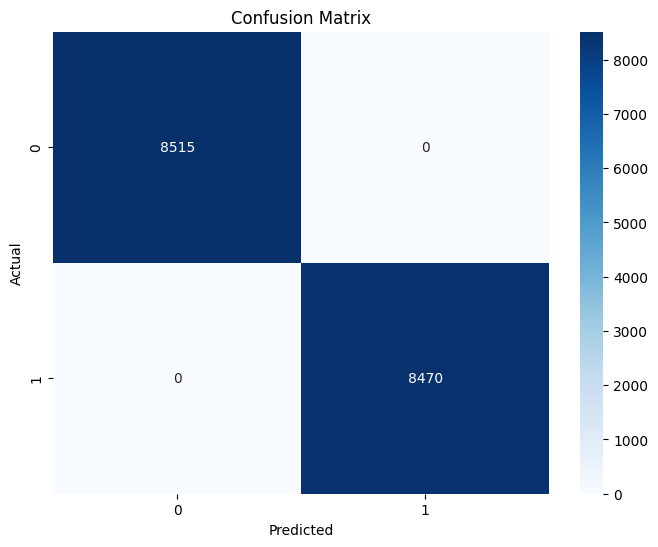

In [37]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png') # save output png
plt.show()

Feature Importances (Top 10):
                                     Feature  Importance
19                 Survival Rate (5-Year, %)    0.232364
16                           Tumor Size (cm)    0.194890
20                   Cost of Treatment (USD)    0.193288
21  Economic Burden (Lost Workdays per Year)    0.187912
17                              Cancer Stage    0.158178
18                            Treatment Type    0.033316
1                                        Age    0.000019
0                                    Country    0.000009
8                          Poor Oral Hygiene    0.000006
11                 Compromised Immune System    0.000003


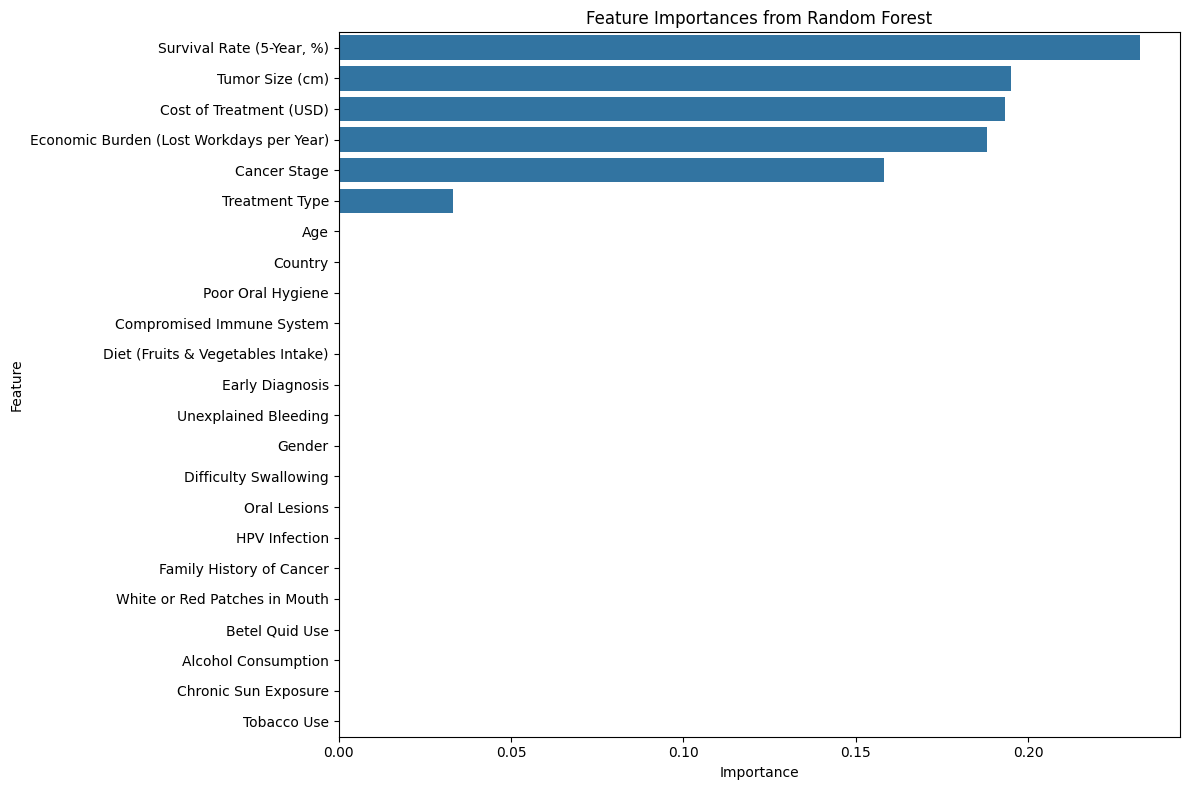

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from the trained Random Forest model
feature_importances = rf.feature_importances_

# Get feature names from the X (features) DataFrame
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances (Top 10):")
print(importance_df.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importances.png') # save output png
plt.show()

In [36]:
import os
from sklearn.metrics import classification_report

# Get the classification report as a string
report_str = classification_report(y_test, y_pred, output_dict=False)

# Define the HTML filename
html_filename = 'model_evaluation_report.html'
image_filename = 'confusion_matrix.png'

# Create the HTML content
html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>Model Evaluation Report</title>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 20px; }}
        h1 {{ color: #333; }}
        pre {{ background-color: #f4f4f4; padding: 10px; border: 1px solid #ddd; overflow-x: auto; }}
        img {{ max-width: 100%; height: auto; display: block; margin-top: 20px; border: 1px solid #ddd; }}
    </style>
</head>
<body>
    <h1>Random Forest Model Evaluation</h1>

    <h2>Classification Report</h2>
    <pre>{report_str}</pre>

    <h2>Confusion Matrix</h2>
"""

# Check if the confusion matrix image exists before embedding
if os.path.exists(image_filename):
    html_content += f"    <img src=\"{image_filename}\" alt=\"Confusion Matrix\">\n"
else:
    html_content += f"    <p>Confusion matrix image ({image_filename}) not found.</p>\n"

html_content += f"""
</body>
</html>
"""

# Write the HTML content to a file
with open(html_filename, 'w') as f:
    f.write(html_content)

print(f"Model evaluation report saved to {html_filename}")
print(f"The confusion matrix image was expected to be at: {image_filename}")

Model evaluation report saved to model_evaluation_report.html
The confusion matrix image was expected to be at: confusion_matrix.png
